In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sessions = pd.read_csv("D:\\E-Commerce-Project\\dataset\\sessions.csv")

In [3]:
sessions.head()

,session_id,user_id,start_time,device_type,referrer_source,is_converted
0,6d553c2d-fe1e-4406-9e32-cd258df05830,0000780a-2126-4e84-9622-42ce0ea9b17a,2023-01-16 12:57:18.000000115,desktop,organic_search,False
1,7330ad09-21cd-4849-b1c8-528d72f7d23b,0000780a-2126-4e84-9622-42ce0ea9b17a,2023-01-18 09:20:23.000000548,desktop,display_ad,False
2,6f6dce62-c078-4dfd-b39b-33068358bc0a,000aea63-23ad-42ab-98b8-3de2e33c624c,2024-10-17 02:05:24.000000257,desktop,direct,False
3,d3a0ecd7-69c3-431e-bab2-89946ce644c1,000b86cc-387b-4968-aaa5-7152296985d2,2026-02-11 03:24:48.000000440,mobile,direct,False
4,1539d203-2ced-4a39-b32c-79caf3b0db72,000b86cc-387b-4968-aaa5-7152296985d2,2026-02-12 16:41:52.000000696,mobile,organic_search,False


In [4]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 19315 entries, 0 to 19314
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   session_id       19315 non-null  str  
 1   user_id          19315 non-null  str  
 2   start_time       19315 non-null  str  
 3   device_type      19315 non-null  str  
 4   referrer_source  19315 non-null  str  
 5   is_converted     19315 non-null  bool 
dtypes: bool(1), str(5)
memory usage: 2.9 MB


In [5]:
sessions.isnull().sum()

session_id         0
user_id            0
start_time         0
device_type        0
referrer_source    0
is_converted       0
dtype: int64

In [10]:
sessions['session_id'].is_unique

True

In [8]:
sessions['user_id'].duplicated().sum()

np.int64(12371)

In [9]:
sessions['user_id'].value_counts().head(10)

user_id
2603c13e-2c0e-4098-9656-0da109a9dbfb    15
a62fcf77-10b9-418b-aadc-e90e9d506e49    14
09bff665-28fa-4f17-8b76-01d7eea5fd67    13
0c19d6da-9401-45f3-a632-3f4c09ff10a3    13
5058b338-dcf9-423c-90a8-adb863c52780    13
06a9247f-696e-4efc-ab44-cc97e7383d6e    12
9537cda8-8d6c-4138-9a0d-c854c8f84d7a    12
aec3788d-434c-4e3a-a8bd-e00ff3a0e9a2    12
b71d133c-b5e8-4031-8500-370e46f983a6    12
ca7b4adc-7ae3-44a2-a075-3c2864b53ebc    12
Name: count, dtype: int64

### Observation

- The `user_id` column contains repeated values, which is expected because a single user can have multiple browsing sessions.
- A total of **12,371 repeated user IDs** were found.
- This is **not a data quality issue** and does not require any cleaning.
- The `session_id` column serves as the unique identifier for each browsing session.

In [16]:
sessions["start_time"] = pd.to_datetime(sessions["start_time"])

In [17]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 19315 entries, 0 to 19314
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   session_id       19315 non-null  str           
 1   user_id          19315 non-null  str           
 2   start_time       19315 non-null  datetime64[ns]
 3   device_type      19315 non-null  str           
 4   referrer_source  19315 non-null  str           
 5   is_converted     19315 non-null  bool          
dtypes: bool(1), datetime64[ns](1), str(4)
memory usage: 2.4 MB


In [20]:
sessions['device_type'].value_counts()

device_type
mobile     11069
desktop     6236
tablet      2010
Name: count, dtype: int64

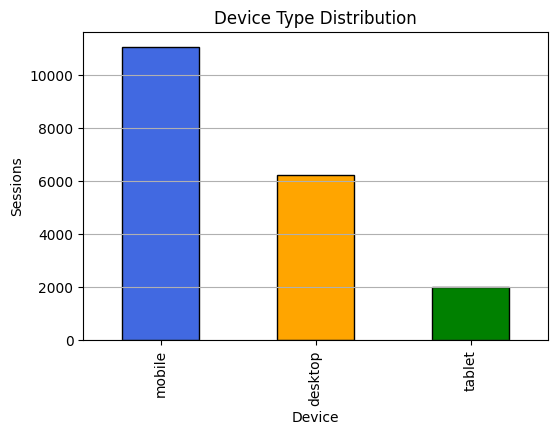

In [19]:
device = sessions["device_type"].value_counts()

plt.figure(figsize=(6,4))

device.plot(
    kind="bar",
    color=["royalblue","orange","green"],
    edgecolor="black"
)

plt.title("Device Type Distribution")
plt.xlabel("Device")
plt.ylabel("Sessions")

plt.grid(axis="y")

plt.show()

In [21]:
sessions["referrer_source"].value_counts()

referrer_source
organic_search    6950
direct            4742
social_media      2833
email             1888
paid_search       1509
referral          1008
display_ad         385
Name: count, dtype: int64

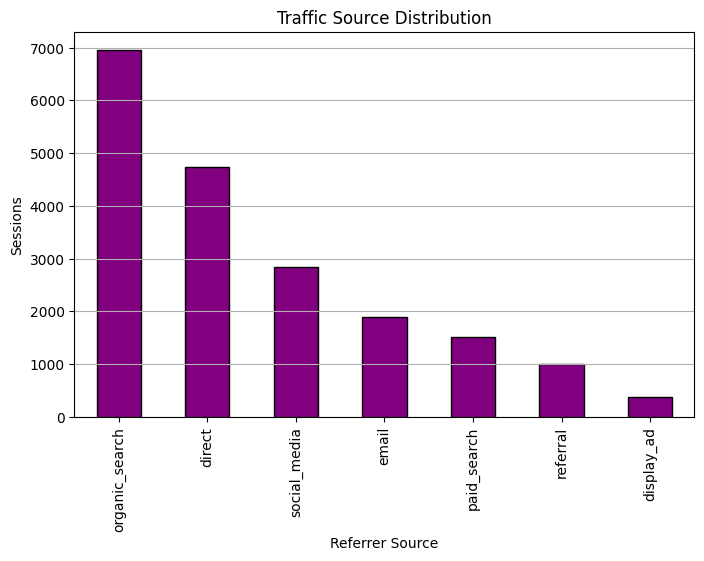

In [22]:
ref = sessions["referrer_source"].value_counts()

plt.figure(figsize=(8,5))

ref.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Traffic Source Distribution")
plt.xlabel("Referrer Source")
plt.ylabel("Sessions")

plt.grid(axis="y")

plt.show()

In [23]:
sessions["is_converted"].value_counts()

is_converted
False    17875
True      1440
Name: count, dtype: int64

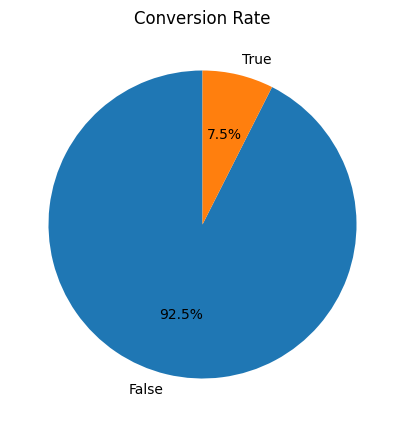

In [24]:
conversion = sessions["is_converted"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    conversion,
    labels=conversion.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Conversion Rate")

plt.show()

In [25]:
sessions["Year"] = sessions["start_time"].dt.year

sessions["Year"].value_counts().sort_index()

Year
2023    3668
2024    5659
2025    7010
2026    2978
Name: count, dtype: int64

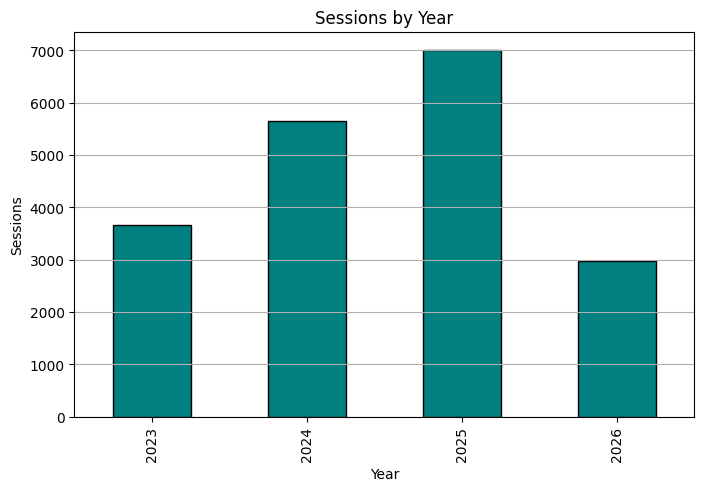

In [ ]:
sessions["Year"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5),
    color="teal",
    edgecolor="black"
)

plt.title("Sessions by Year")

plt.xlabel("Year")

plt.ylabel("Sessions")

plt.grid(axis="y")

plt.show()

In [ ]:
sessions.to_csv(
    "cleaned_data/sessions_cleaned.csv",
    index=False
)